(sec:modello-esponenziale)=
# Il modello esponenziale

Data una successione $p_1, p_2, \dots, p_n, \dots$ di valori tali
che $p_i \in (0, 1]$ per ogni $i \in \mathbb N$, consideriamo la famiglia
di variabili aleatorie geometirche
$\{ X_i \sim \mathrm G(p_n), i \in \mathbb N \}$. Per
quanto abbiamo visto  nel {numref}`Paragrafo %s <sec:modello-geometrico>`,
la funzione di ripartizione di ogni $X_i$ sarà

```{math}
F_{X_i}(x; p_i) = 1 - (1 - p_i)^{\lfloor x \rfloor + 1} \mathrm
            I_{\mathbb N \cup \{0\}}(x) \enspace.
```

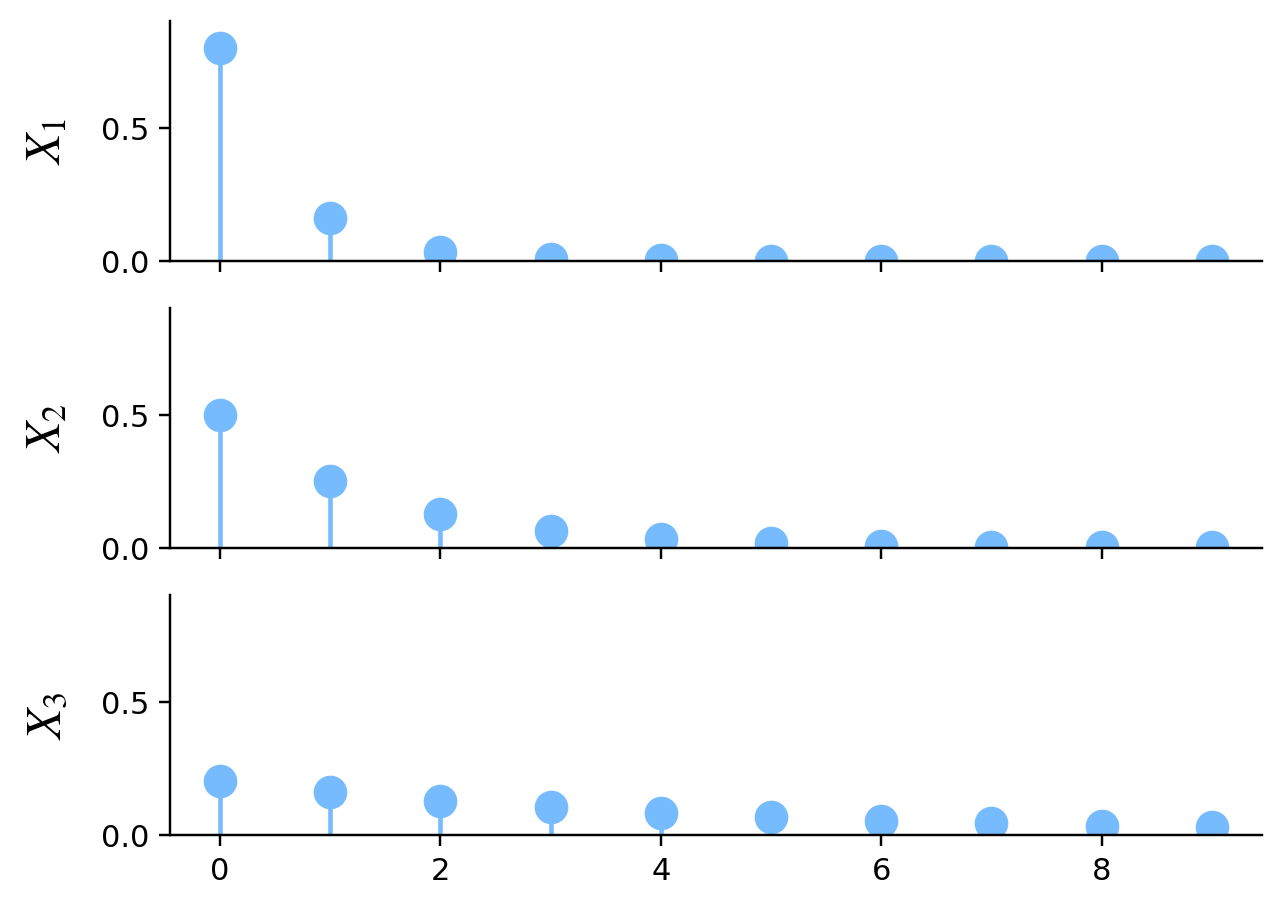

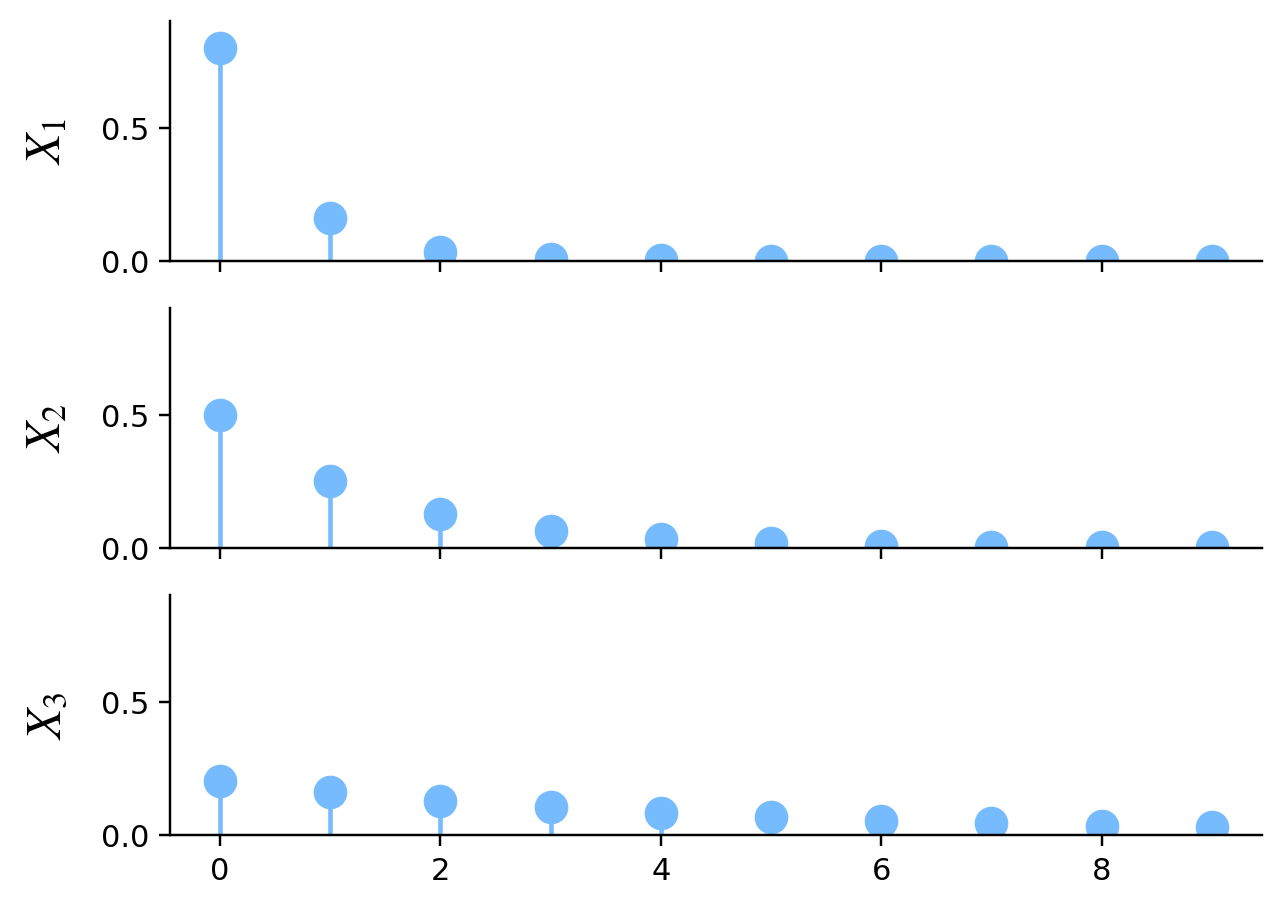

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
from myst_nb import glue

ps = [0.8, 0.5, 0.2]

Xs = [st.geom(p, loc=-1) for p in ps]

x = np.arange(0, 100)

fig, axes = plt.subplots(len(ps), 1, sharex=True)

for i, (ax, X) in enumerate(zip(axes, Xs)):
    pdf = X.pmf(x)
    ax.vlines(x[:10], 0, pdf[:10])
    ax.plot(x[:10], pdf[:10], 'o')
    ax.set_ylim(0, 0.9)
    ax.set_ylabel(rf'$X_{i+1}$')
plt.show()

glue("geometric-divergence", fig)

```{glue:figure} geometric-divergence
:name: fig:geometric-divergence
:figwidth: 300px

Grafici della funzione di massa di probabilità di $X_i$ per $i = 1, 2, 3$,
$p_1 = 0.8$, $p_2 = 0.5$ e $p_3 = 0.2$.
```

Dato $\lambda \in [0, +\infty)$, definiamo $Y_i = \frac{p_i}{\lambda} X_i$ per
ogni $i \in \mathbb N$. In altre
parole, $Y$ si ottiene scalando $X$ di un fattore opportuno e ciò porta ad
«addensare» i relativi punti di massa di quest'ultima (che vengono divisi per
una quantità positiva e moltiplicati per un valore tra zero e uno).

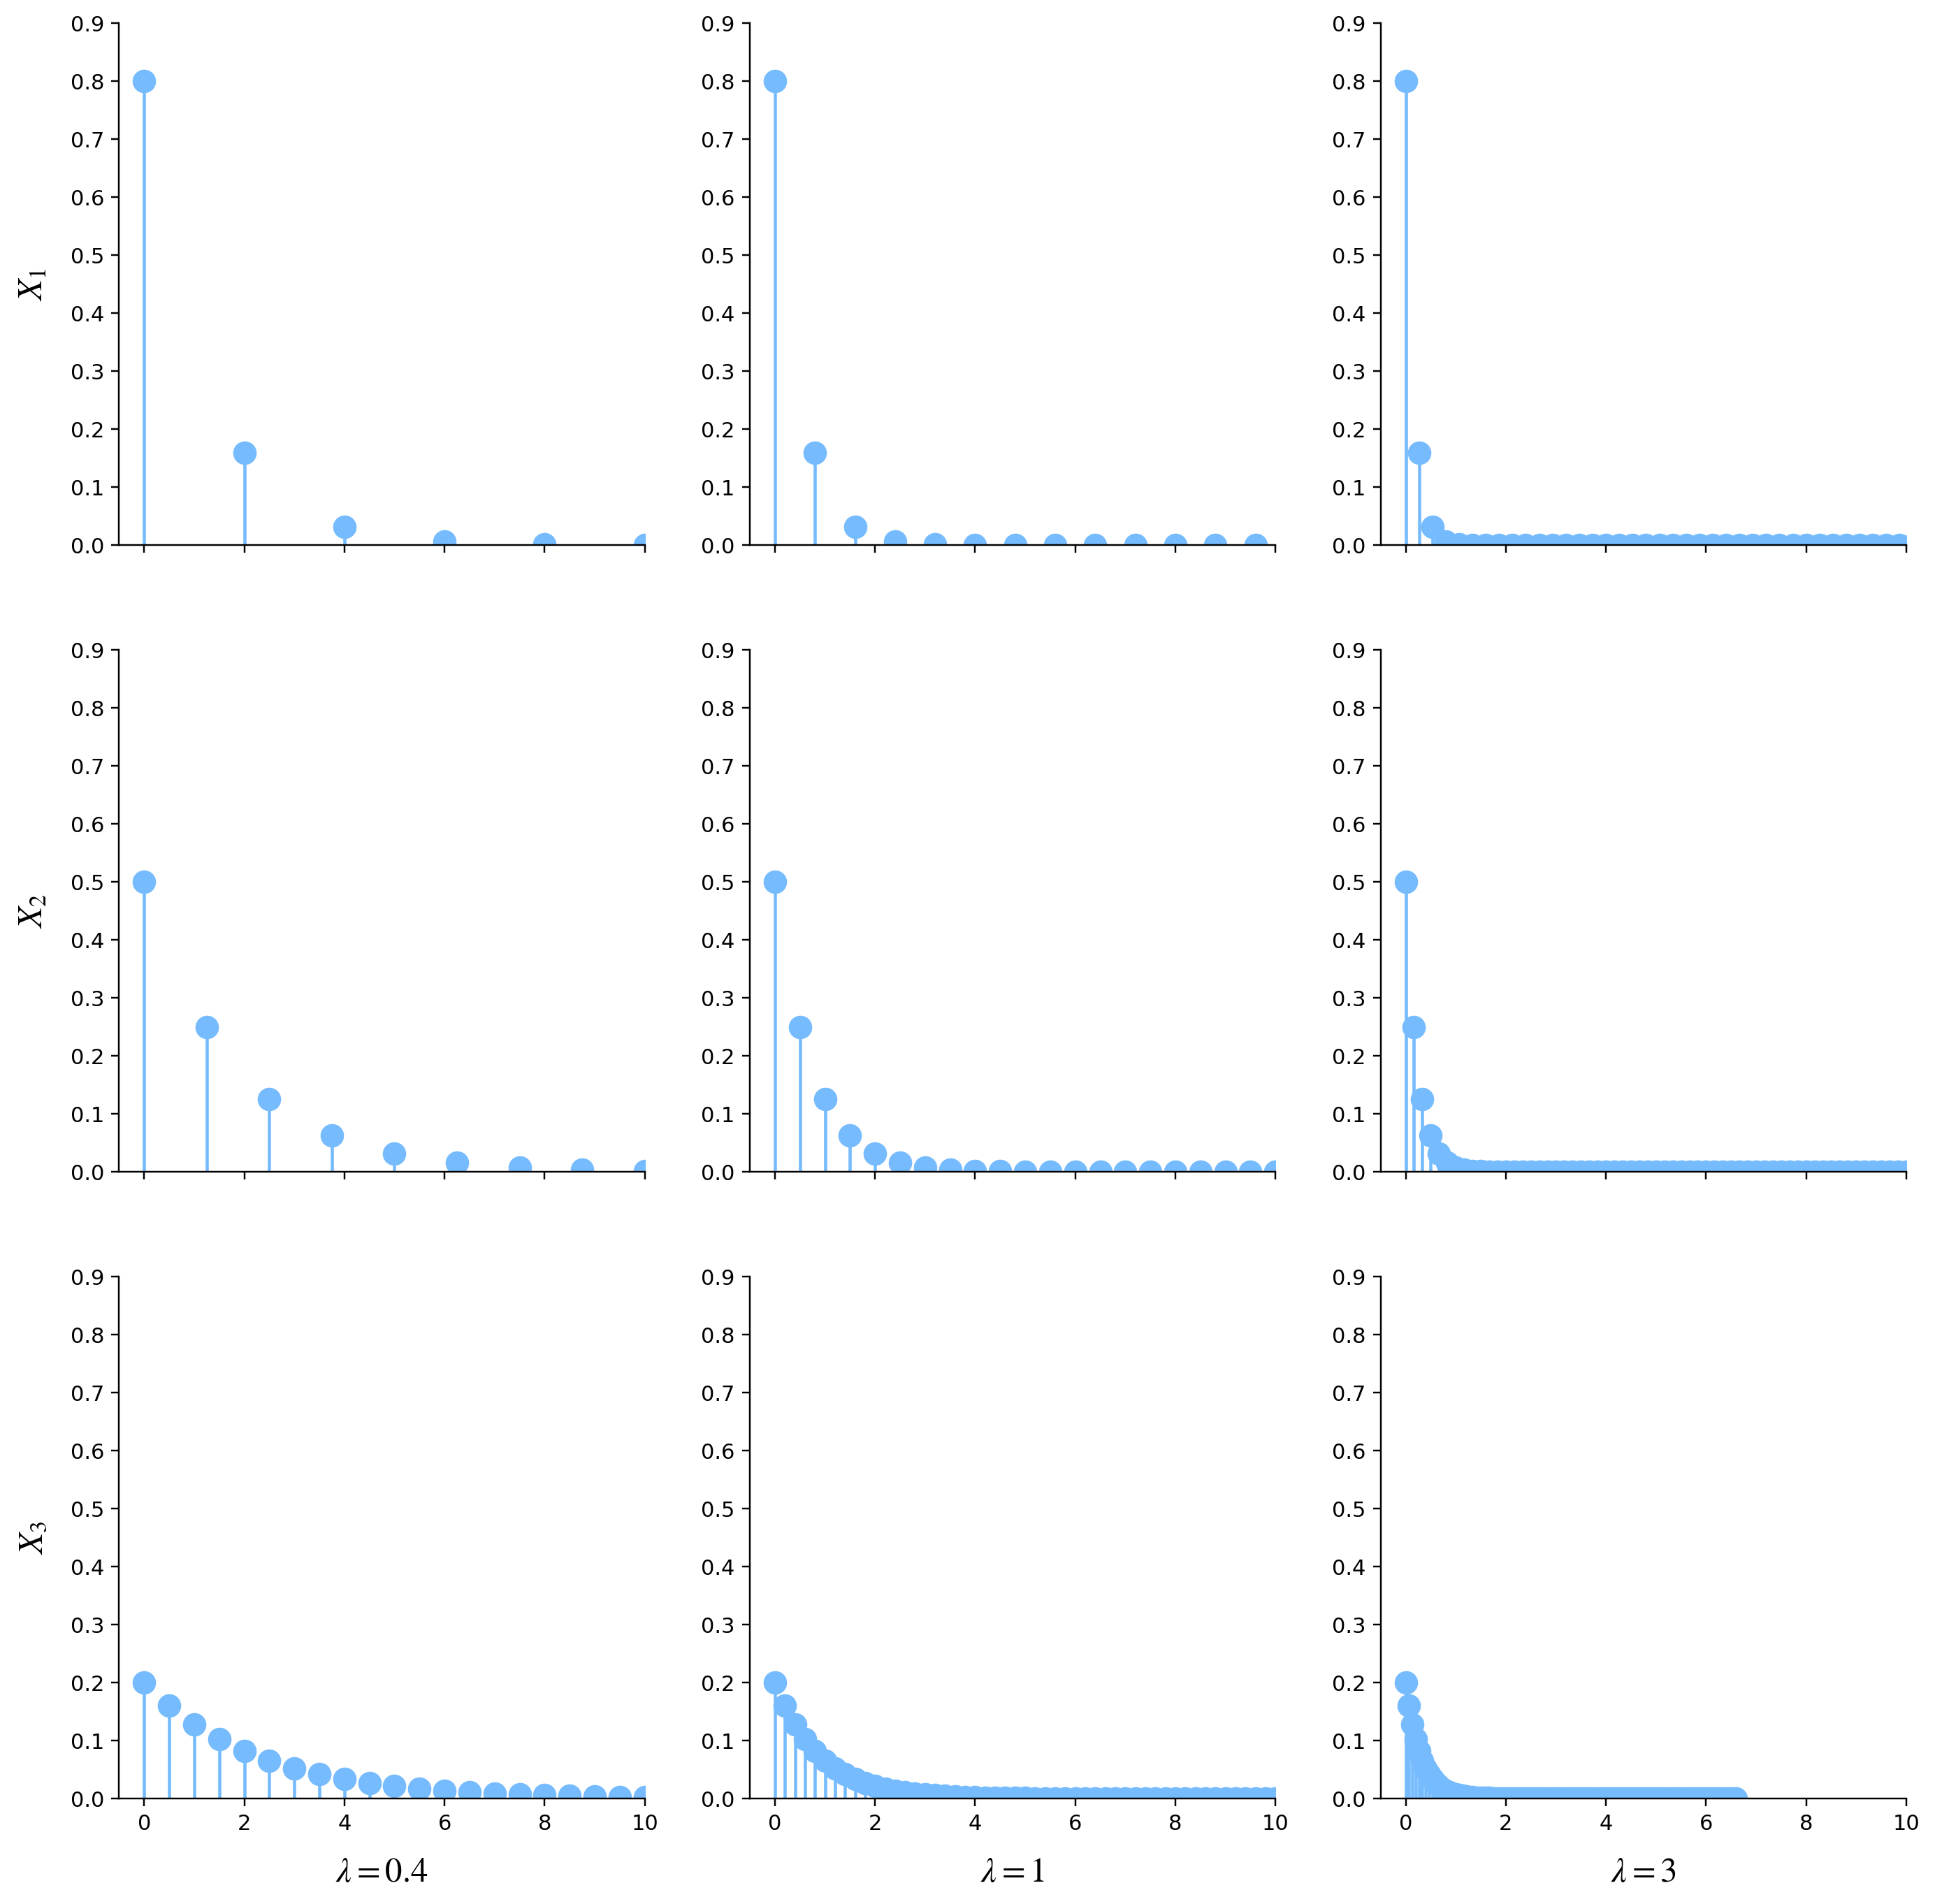

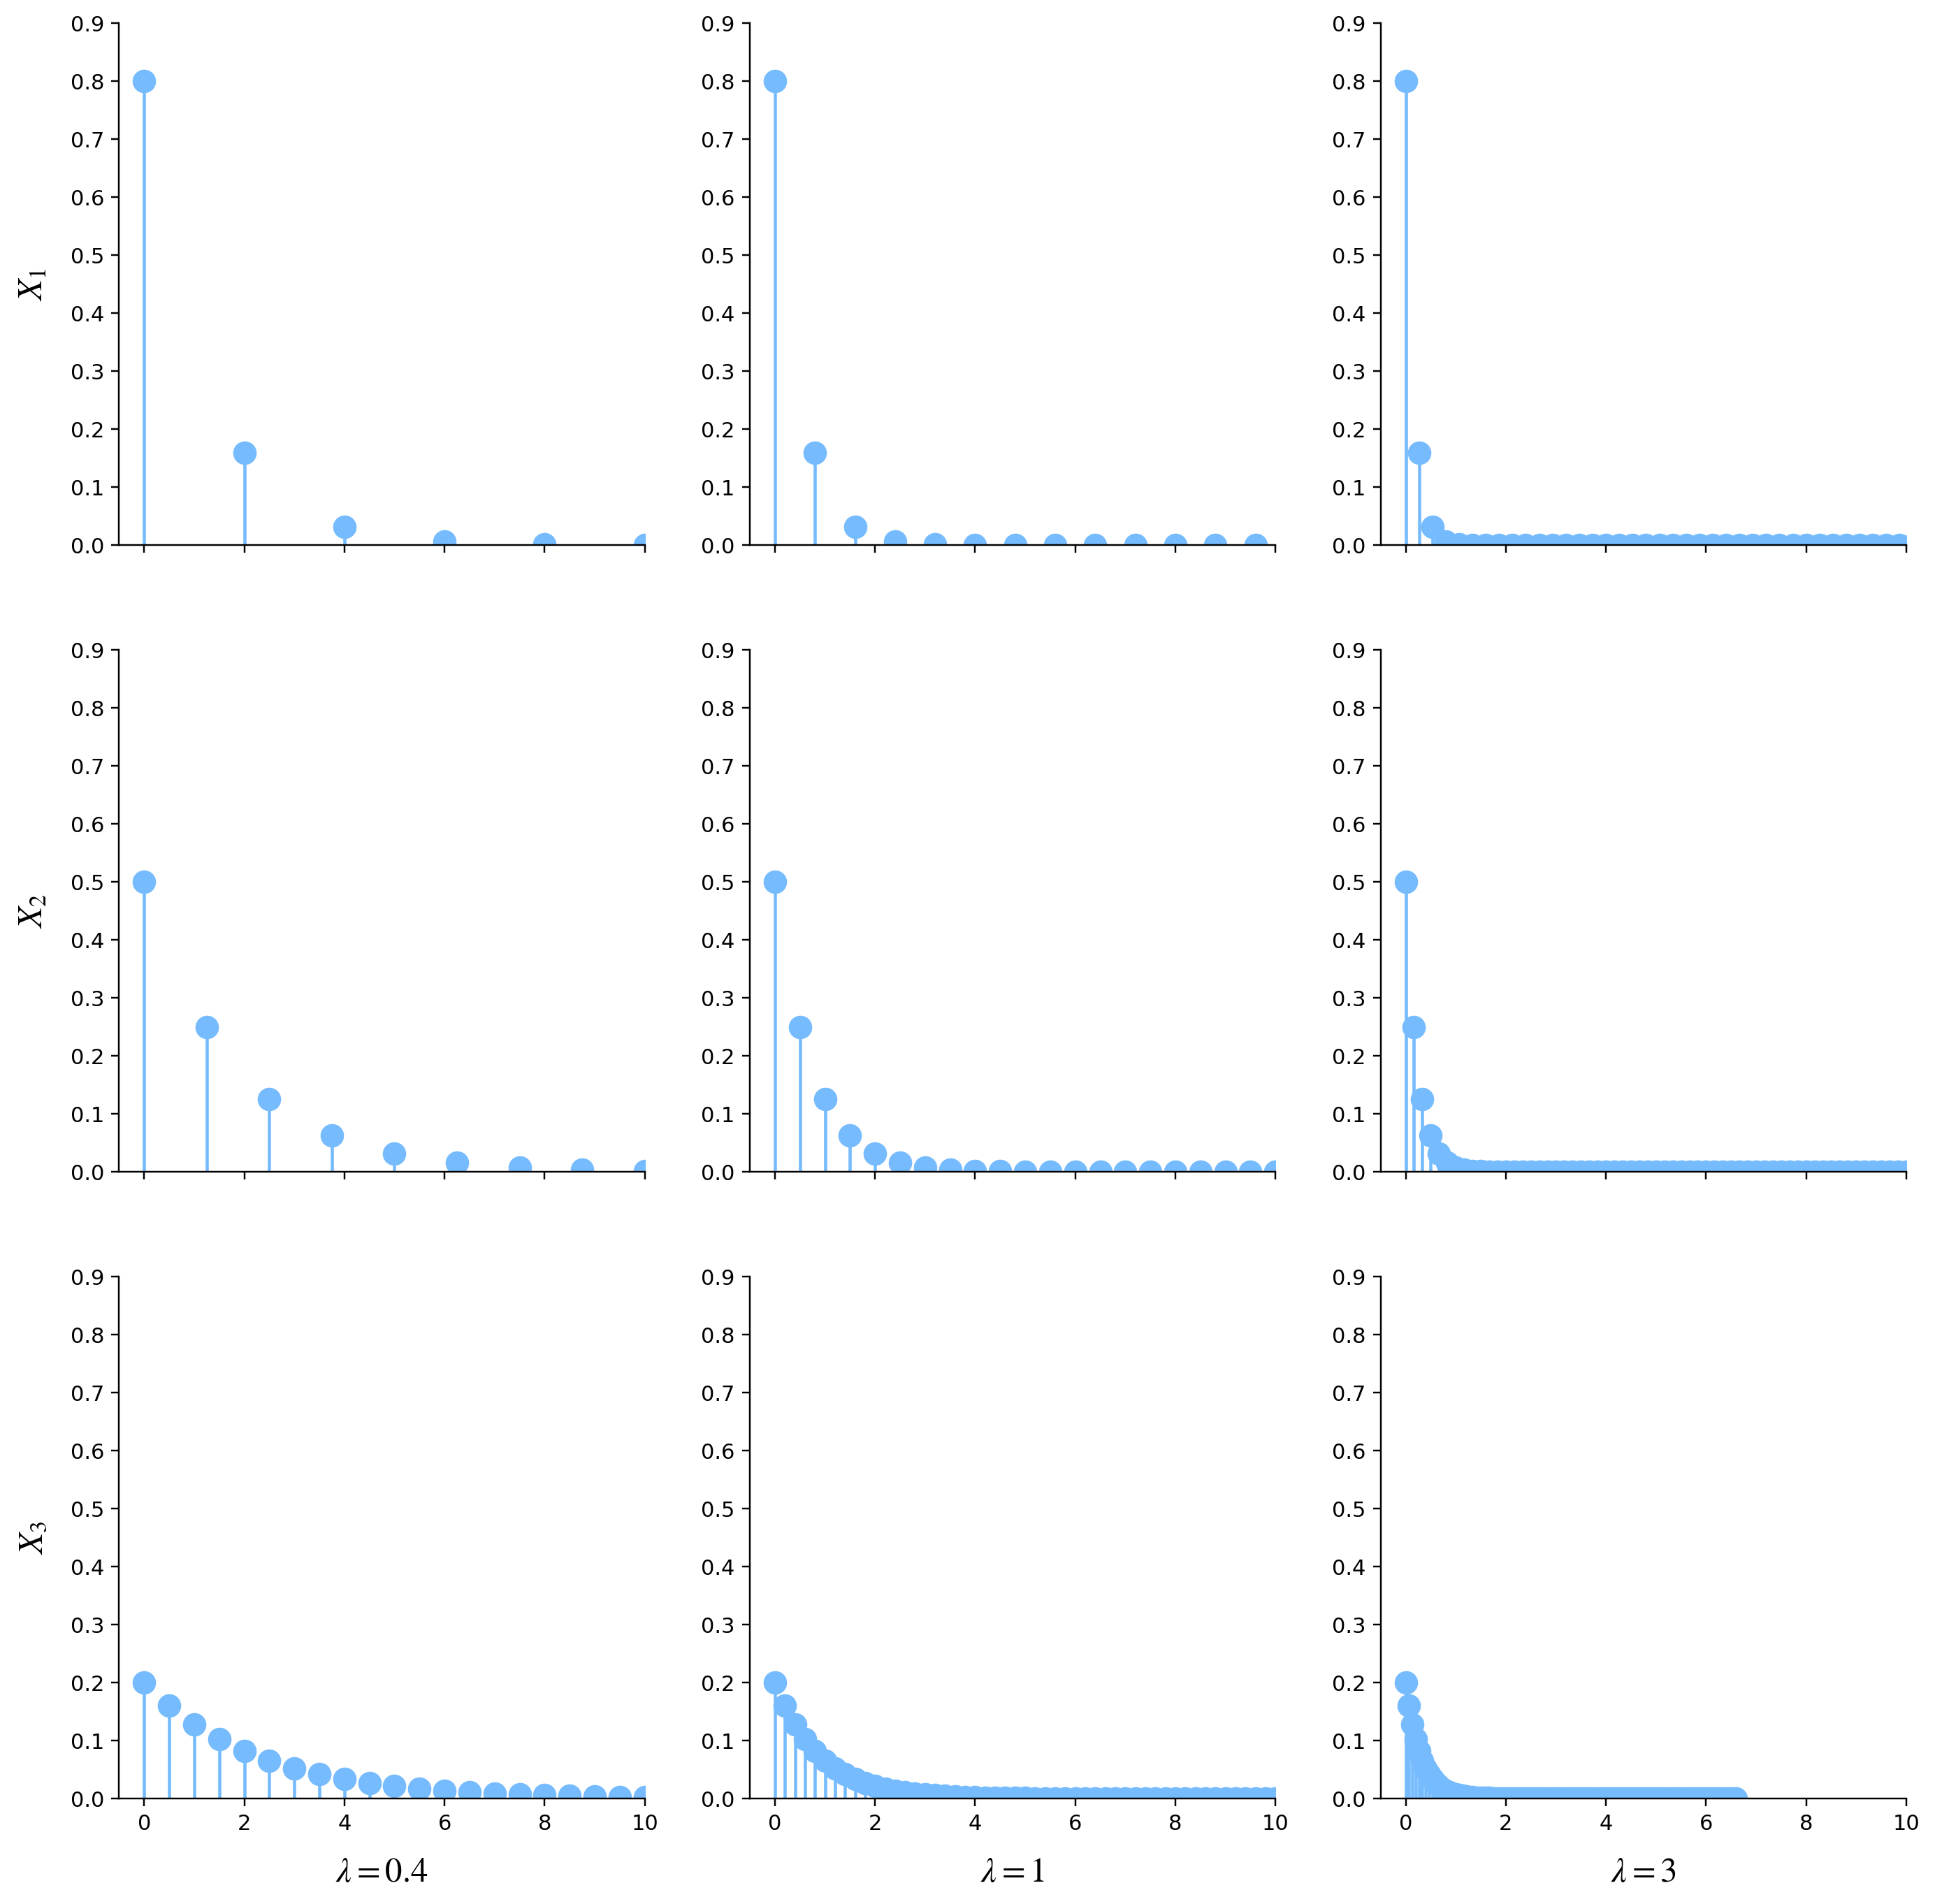

In [2]:
lambdas = [0.4, 1, 3]

fig, axes = plt.subplots(len(ps), 3, sharex=True, figsize=(15, 15))

for col, lambda_ in zip(axes.T, lambdas):
    for ax, X, p in zip(col, Xs, ps):
        y = x * p / lambda_
        pdf = X.pmf(x)
        ax.vlines(y, 0, pdf)
        ax.plot(y, pdf, 'o')
        ax.set_xlim(-0.5, 10)
        ax.set_ylim(0, 0.9)

for i, (ax, p) in enumerate(zip(axes.T[0], ps)):
    ax.set_ylabel(rf'$X_{i+1}$')

for i, (ax, lambda_) in enumerate(zip(axes[-1], lambdas)):
    ax.set_xlabel(rf'$\lambda = {lambda_}$')

plt.show()

glue("geometric-convergence", fig)

```{glue:figure} geometric-convergence
:name: fig:geometric-convergence

Grafici della funzione di massa di probabilità delle variabili aleatorie $Y_i$
ottenute dalle corrispondenti $X_i$ della
{numref}`Figura %s <fig:geometric-divergence>`. Ogni colonna fa riferimento
a un valore differente per $\lambda$.
```

La funzione di ripartizione delle $Y_i$ è nulla per ogni argomento negativo.
Concentrandosi invece sugli argomenti non negativi, si ha

```{math}
F_{Y_i}(x; p_i, \lambda) = \mathbb P(Y_i \leq x) 
                      = \mathbb P\left(X_i \leq \frac{\lambda}{p_i} x \right)
                      = F_{X_i}\left(\frac{\lambda}{p_i} x; p_i \right)
                      = 1 - (1 - p_i)^{\left\lfloor \frac{\lambda x}{p_i}
                                            \right\rfloor + 1} \enspace.
```

```{margin}
In questo caso stiamo sfruttando il fatto che
$x - 1 \leq \lfloor x \rfloor \leq x$ (vedi
{numref}`Paragrafo %s <sec:dal-discreto-al-continuo>`) unitamente al fatto che
l'elevamentobfatto con base $1 - p$ è un'operazione monotona non crescente.
```
Concentriamoci sulla quantità
$(1 - p)^{\left\lfloor \frac{\lambda x}{p} \right\rfloor + 1}$, notando che
vale

```{math}
:label: eq:geometric-to-exponential
(1 - p)^{\frac{\lambda x}{p}} \geq
(1 - p)^{\left\lfloor \frac{\lambda x}{p} \right\rfloor + 1} \geq
(1 - p)^{\frac{\lambda x}{p} + 1}.
```

Studiamo il limite per $p \to 0$ della quantità a sinistra di questa catena
di disuguaglianze:

```{margin}
Si verifica facilmente che $\lim_{p \to 0}\frac{\ln(1 - p)}{p} = -1$ applicando
il teorema di de l'Hôpital.
```
```{math}
\lim_{p \to 0} (1 - p)^{\frac{\lambda x}{p}}
 = \lim_{p \to 0} \mathrm e^{\ln (1 - p)^{\frac{\lambda x}{p}}}
 = \lim_{p \to 0} \mathrm e^{\lambda x \frac{\ln (1 - p)}{p}}
 = \mathrm e^{-\lambda x} \enspace.
```
D'altra parte, per quanto riguarda la quantità più a destra in
{eq}`eq:geometric-to-exponential` si ha che

```{math}
\lim_{p \to 0}(1 - p)^{\frac{\lambda x}{p} + 1}
= \lim_{p \to 0}(1 - p)^{\frac{\lambda x}{p}}
  -\lim_{p \to 0} p (1 - p)^{\frac{\lambda x}{p}}
  = \mathrm e^{-\lambda x} - 0 \enspace,
```

pertanto applicando il teorema dei due Carabinieri si ottiene

```{math}
\lim_{p_i \to 0} F(x; p_i, \lambda) = 1 - \mathrm e^{-\lambda x} \enspace.
```

Riassumendo, le distribuzioni delle $Y_i$ tendono a una distribuzione
continua caratterizzata dalla ripartizione

```{margin}
Si verifica facilmente che $F$ soddisfa i requisiti che definiscono una
funzione di ripartizione continua.
```
```{math}
:label: eq:cdf-exponential
F(x; \lambda) \coloneqq
     \left(1 - \mathrm e^{-\lambda x} \right) \; \mathrm I_{\mathbb R^+}(x)
     \enspace .
```     

e dalla densità che si ottiene derivando questa stessa funzione:

```{math}
:label: eq:pdf-exponential
f(x; \lambda) = F'(x; \lambda) = \lambda \mathrm e^{-\lambda x}
                \; \mathrm I_{\mathbb R^+}(x) \enspace ,
```

che si verifica facilmente avere integrale su $\mathbb R$ uguale a $1$,
sostituendo nell'integranda $y \coloneqq \lambda x$:

```{margin}
Gli estremi di integrazione non vanno scambiati perché $\lambda$ non è mai
negativo.
```
```{math}
\int_{-\infty}^{+\infty} f(x; \lambda) \; \mathrm d x
      = \int_{0}^{+\infty} \lambda \mathrm e^{-\lambda x} \; \mathrm d x
      = \int_{0}^{+\infty} \mathrm e^{-y} \; \mathrm d y
      = \left. -\mathrm e^{-y} \right|_0^{+\infty}
      = -0 + 1 = 1 \enspace .
```

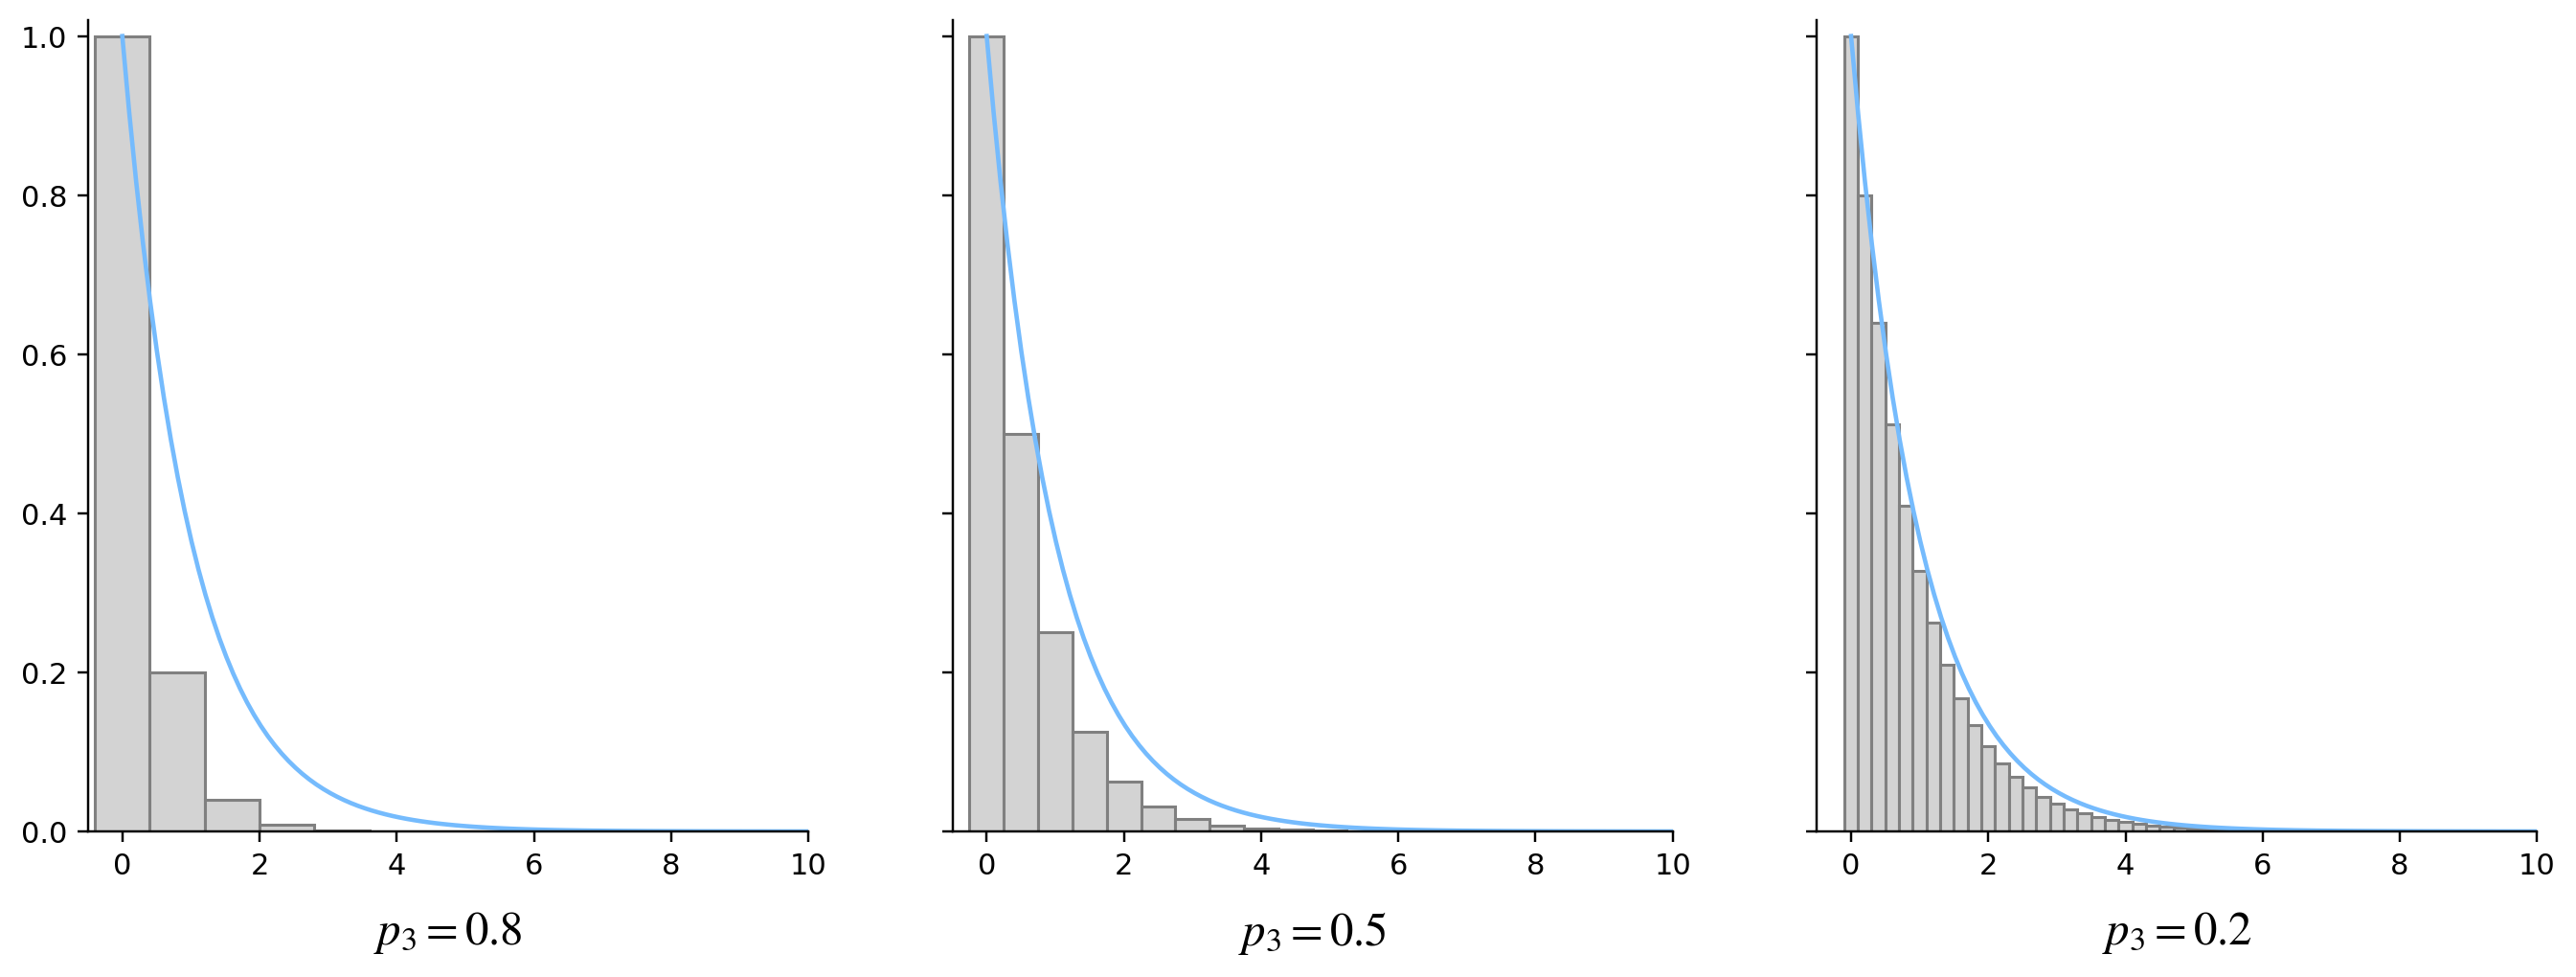

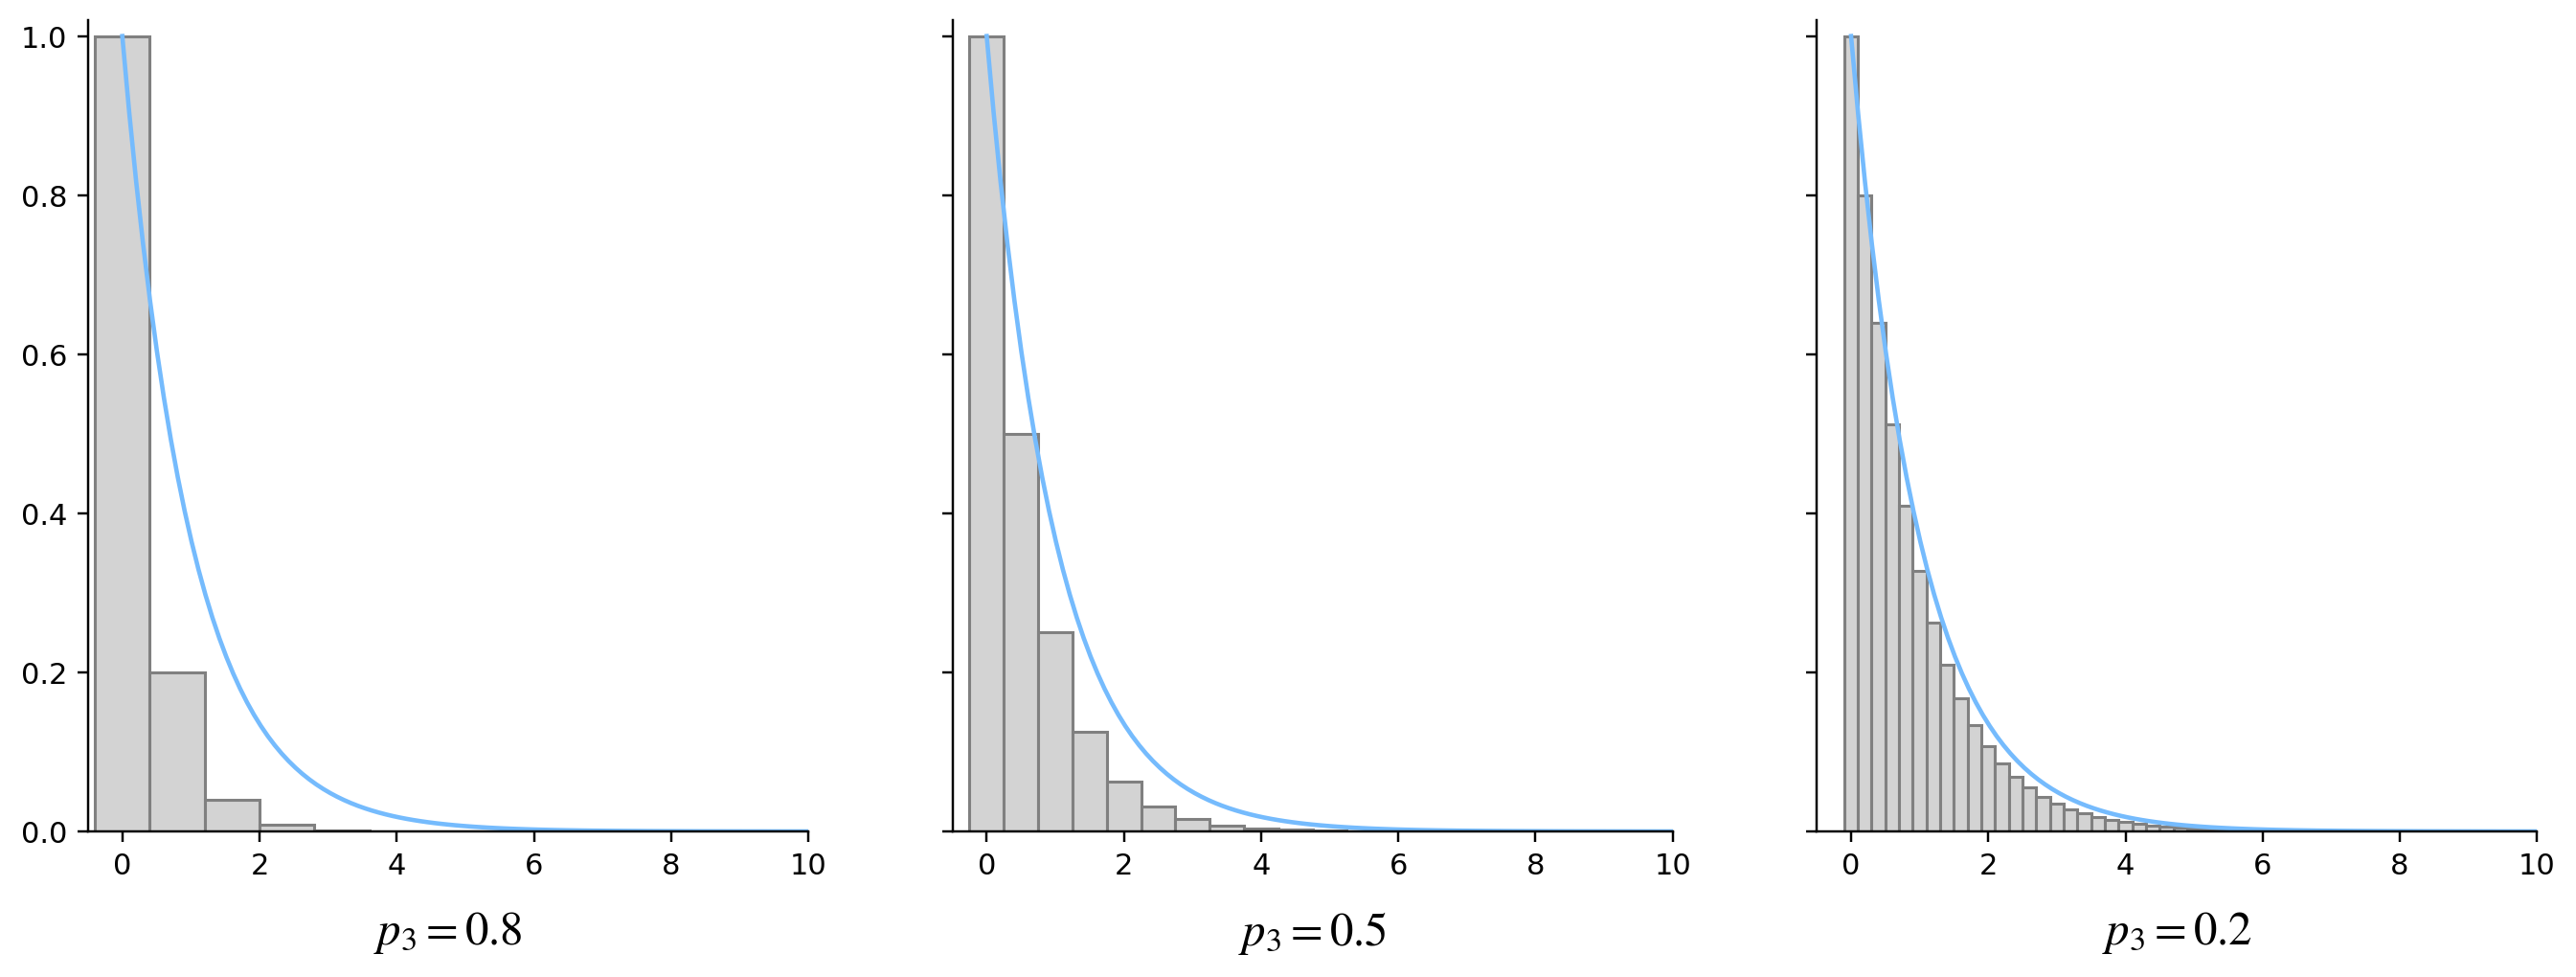

In [3]:
def exponential_pdf(x, lambda_):
    return lambda_ * np.exp(-lambda_ * x)

fig, axes = plt.subplots(1, len(ps), sharey=True, figsize=(15, 5))

lambda_ = 1
for ax, X, p in zip(axes, Xs, ps):
    y = x * p / lambda_
    pdf = X.pmf(x) / (p/lambda_)
    ax.bar(y, pdf, color='lightgray', edgecolor='gray', width=p/lambda_)

    ax.set_xlim(-0.5, 10)
    ax.set_ylim(0, 1.02)

    y_exp = np.linspace(0, 10, 100)
    ax.plot(y_exp, exponential_pdf(y_exp, lambda_))
    ax.set_xlabel(rf'$p_{i+1} = {p}$')

glue("geometric-convergence-to-exp", fig)

```{glue:figure} geometric-convergence-to-exp
:name: fig:geometric-convergence-to-exp

Convergenza della distribuzione geometrica a quella esponenziale.
Le barre grige visualizzano l'area delimitata dalle funzioni di densità
ottenute convertendo le funzioni di massa di probabilità delle variabili
aleatorie $Y_i$ mostrate nella colonna centrale della
{numref}`Figura %s <fig:geometric-convergence>`, relative alla scelta
$\lambda = 1$, sovrapposti alla corrispondente funzione di densità di
probabilità {eq}`eq:pdf-exponential`.
```

Usando la stessa tecnica della {numref}`Figura %s <fig:normal-convergence>`,
la {numref}`Figura %s <fig:geometric-convergence-to-exp>` mostra come
le densità ottenute convertendo le funzioni di massa di probabilità
delle variabili aleatorie $Y_i$ tendano alla funzione definita in
{eq}`eq:pdf-exponential`. Riassumendo, siamo di fronte a un nuovo tipo di
distribuzione continua, che viene chiamata _distribuzione esponenziale_ e che
è definita formalmente come seuge, unitamente alla corrispondente famiglia.

````{prf:definition} La famiglia delle distribuzioni esponenziali

Dato $\lambda \in \mathbb R^+$, la  _distribuzione esponenziale_ di parametro
$\lambda$ è definita dalla funzione di densità di probabilità

```{math}
f(x; \lambda) = F'(x; \lambda) = \lambda  \mathrm e^{-\lambda x}
                                 \;\mathrm I_{\mathbb R^+}(x) \enspace,
```

o in modo equivalente dalla funzione di ripartizione

```{math}
F(x; \lambda) = \left(1 - \mathrm e^{-\lambda x} \right)
                \; \mathrm I_{\mathbb R^+}(x) \enspace.
```

Useremo la notazione $X \sim \mathrm E(\lambda)$ per specificare che una
variabile aleatoria $X$ segue una distribuzione esponenziale di parametro
$\lambda$. L'insieme di tutte le distribuzioni esponenziali al variare dei
valori per il relativo parametro $\lambda$ _famiglia delle distribuzioni
esponenziali_.
````

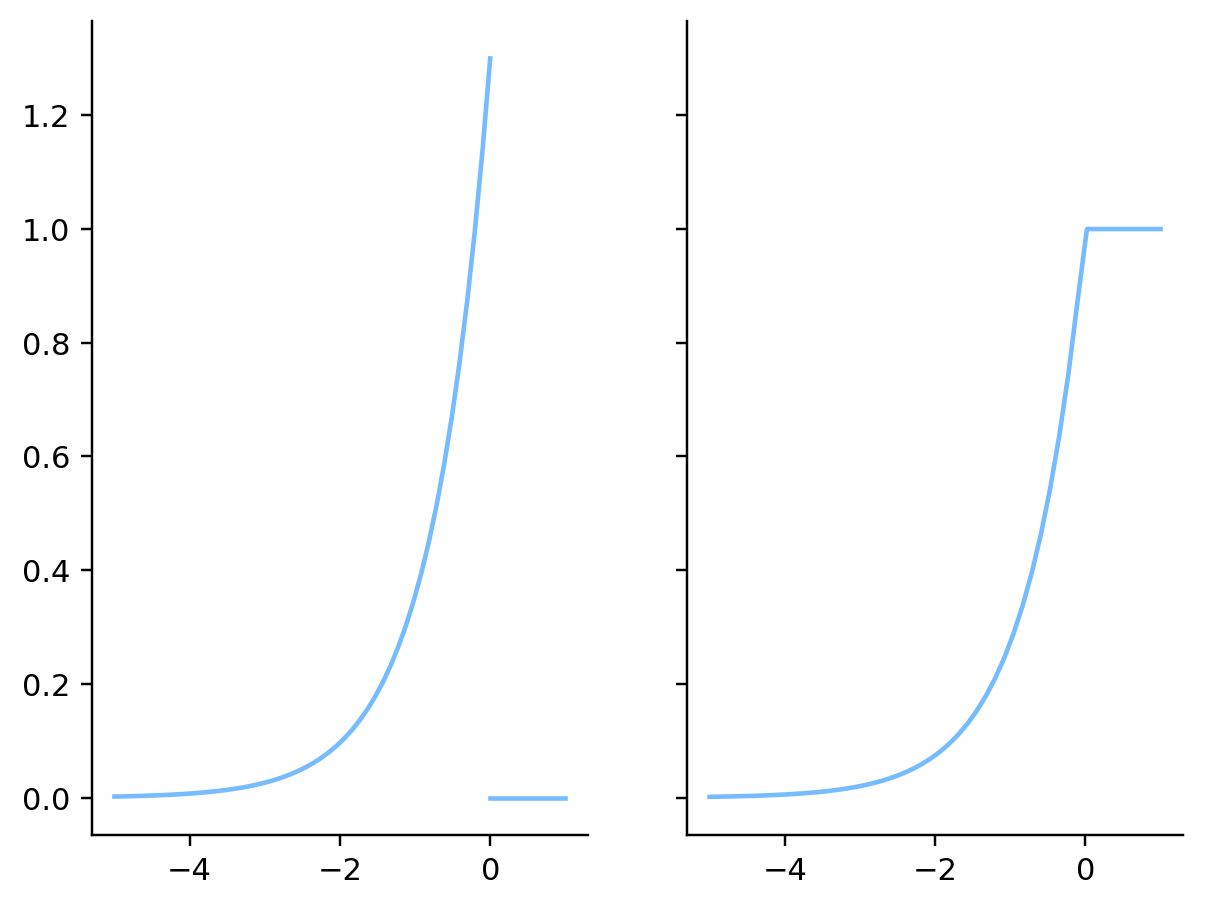

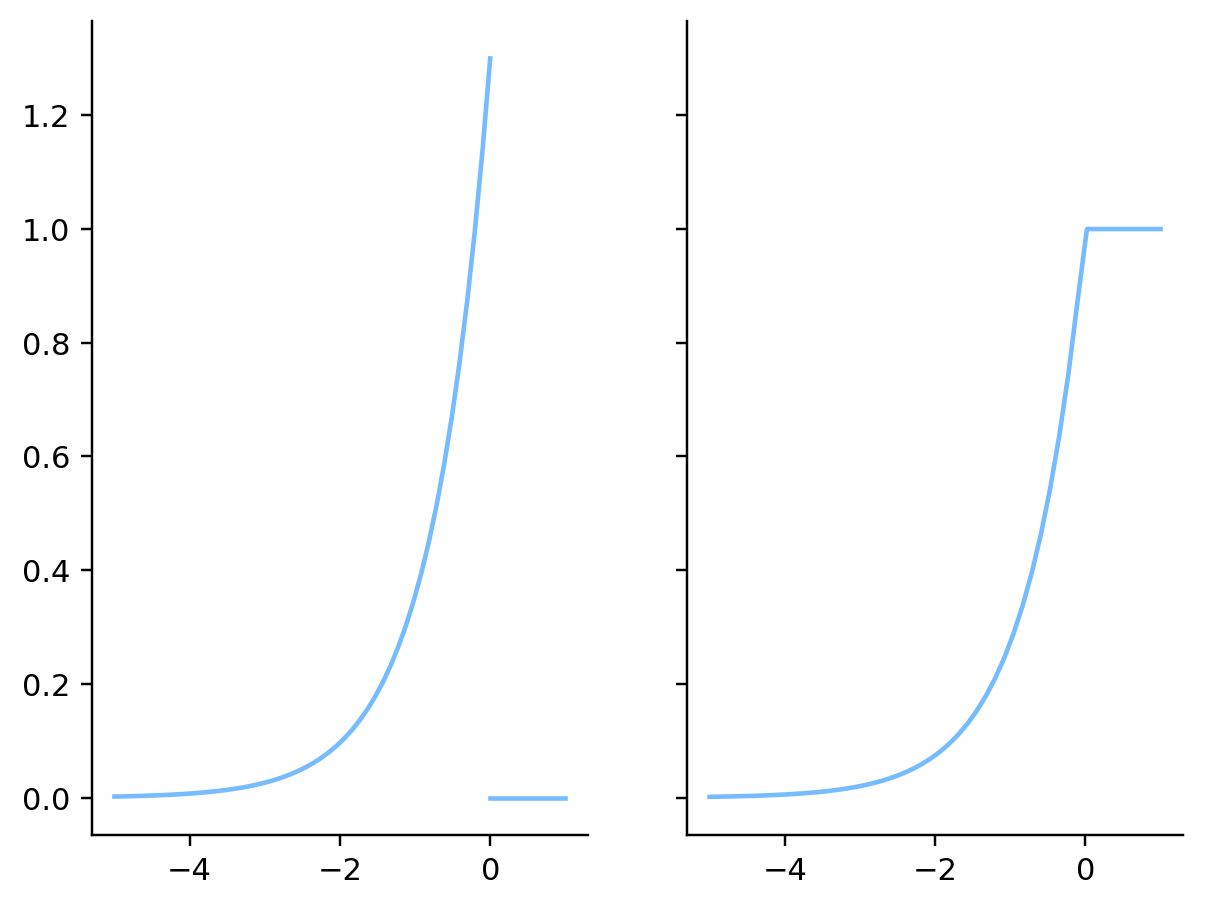

In [4]:
plt.style.use('sds.mplstyle')

lambda_ = 1.3
fig, axes = plt.subplots(1, 2, sharey=True)

x = np.linspace(-5, 0, 50)
y = lambda_ * np.exp(lambda_ * x)
pl = axes[0].plot(x, y)
color = pl[0].get_color()

x = np.linspace(0, 1)
y = [0] * len(x)
axes[0].plot(x, y, color=color)

x = np.linspace(-5, 1, 50)
y = np.exp(lambda_ * x)
y[x>0] = 1
axes[1].plot(x, y)

glue("negative-exp", fig)

```{glue:figure} negative-exp
:name: fig:negative-exponential
:figclass: margin

Grafici delle funzioni di densità (sopra) e di ripartizione (sotto) della
distribuzione esponenziale negativa di parametro $\lambda = 3/2$.
```


````{admonition} Nomenclatura
:class: naming

La distribuzione esponenziale deve il suo nome al ruolo predominante
che la funzione esponenziale (intesa come elevamento di $\mathrm e$ a una
potenza) ha nella definizione delle funzioni di ripartizione e di densità di
probabilità. Il fatto che l'argomento di questa funzione sia sempre negativo
in corrispondenza delle specificazioni della distribuzione porta alcuni testi
a utilizzare il nome «esponenziale negativa». Altre fonti distinguono
invece le distribuzioni esponenziali da quelle esponenziali negative,
usando la prima denominazione esattamente come ho fatto io, e la
seconda per indicare l'equivalente della distribuzione esponenziale in cui
però densità e ripartizione sono ribaltate rispetto all'asse delle ordinate,
portando quindi ad avere $\mathbb R^-$ come insieme delle specificazioni.
Usando questa accezione, una variabile aleatoria $X$ segue una distribuzione
esponenziale negativa di parametro $\lambda$ se e solo se la sua funzione di
densità di probabilità è
```{math}
f_X(x; \lambda) = \lambda \mathrm e^{\lambda x}
                  \mathrm I_{(-\infty, 0]}(x) \enspace.
```

La {numref}`fig:negative-exponential` mostra i grafici della funzione di
densità di probabilità e di ripartizione della distribuzione esponenziale
negativa che corrisponde al parametro $\lambda = 3/2$.

La dicitura «famiglia esponenziale» viene inoltre utilizzata per indicare
un insieme di famiglie di distribuzioni (che comprende, tra le altre,
quelle esponenziali) che godono di particolari proprietà teoriche che in
questo libro non vengono considerate. Si tratta quindi di una famiglia di
famiglie parametriche di distribuzioni, dunque sarebbe più corretto parlare
della meta-famiglia o, come riportato in alcuni testi per essere concisi
evitando nel contempo di incorrere in ambiguità, della classe esponenziale.

Nel seguito non tratterò né la famiglia delle distribuzioni esponenziali
negative, né la classe esponenziale. Pertanto userò
l'aggettivo «esponenziale» per riferirmi solo alle distribuzioni definite in
questo paragrafo, o alla corrispondente famiglia parametrica.
````

Il valore atteso e la varianza delle distribuzioni esponenziali si ottengono
facilmente in funzione del loro parametro, applicando le relative definizioni.
Più precisamente, il valore atteso di $X \sim \mathrm E(\lambda)$ si calcola
tipicamente integrando per parti: definendo $f(x) \coloneqq x$ e
$g(x) \coloneqq \mathrm e^{-\lambda x}$ si ha

```{margin}
L'ultimo integrale è uguale a $1$ perché equivale all'integrale della
densità esponenziale su $\mathbb R$.
```
\begin{align*}
\mathbb E(X) &= \int_{-\infty}^{+\infty} x f_X(x; \lambda) \; \mathrm d x
              = \int_0^{+\infty} \lambda x \mathrm e^{-\lambda x}
                \; \mathrm d x \\
             &= -\int_0^{+\infty} f(x) \cdot g'(x) \; \mathrm d x \\
             &= \underbrace{-x \mathrm e^{-\lambda x} \bigg|_0^{+\infty}}_{=0}
                + \int_0^{+\infty} \mathrm e^{-\lambda x} \; \mathrm d x
              = \frac{1}{\lambda} \underbrace{\int_0^{+\infty}
                        \lambda \mathrm e^{-\lambda x} \; \mathrm d x}_{=1}
              = \frac{1}{\lambda} \enspace.
\end{align*}

Procedendo in modo analogo, ma ponendo $f(x) \coloneqq x^2$, si ottiene

```{margin}
In questo caso, l'ultimo integrale è uguale a $1 / \lambda$ perché il suo
calcolo è lo stesso del valore atteso della distribuzione esponenziale di
parametro $\lambda$.
```
\begin{align*}
\mathbb E(X^2) &= \int_0^{+\infty}\lambda x^2 \mathrm e^{-\lambda x}
                  \;\mathrm d x
                = -\int_0^{+\infty} f(x) g'(x) \;\mathrm d x \\
               &= \underbrace{-x^2 \mathrm e^{-\lambda x}
                              \bigg|_0^{+\infty}}_{=0} +
                  2 \int_0^{+\infty} x \mathrm e^{-\lambda x}
                                \; \mathrm d x \\
               &= \frac{2}{\lambda} \underbrace{\int_0^{+\infty}
                                \lambda x \mathrm e^{-\lambda x}
                                \; \mathrm d x}_{= 1 / \lambda}
                = \frac{2}{\lambda^2} \enspace.
\end{align*}

Pertanto $\mathrm{Var}(X) = \frac{2}{\lambda^2} - \frac{1}{\lambda^2} =
\frac{1}{\lambda^2}$.

La famiglia delle distribuzioni esponenziali gode di una particolare
proprietà di chiusura rispetto alla scalatura delle sue specificazioni,
come indicato in dettaglio di seguito.

````{prf:lemma}
Dati $\lambda \in \mathbb R^+$ e $X \sim \mathrm E(\lambda)$, posto
$c > 0$ e definita $Y \coloneqq X/c$, si ha che $Y \sim \mathrm E(\lambda c)$.
```{prf:proof}
La funzione di ripartizione di $Y$ è tale che per ogni $x \in \mathbb R$,
tenuto conto del fatto che $c$ è positivo,

\begin{equation*}
F_Y (x) = \mathbb P(Y \leq x) = \mathbb P(X \leq c x) = F_X(c x)
        = 1 - \mathrm e^{-\lambda c x} \enspace.
\end{equation*}

Nell'ultimo membro di questa uguaglianza si riconosce facilmente la
ripartizione di una distribuzione esponenziale di parametro $\lambda c$.
```
````

La distribuzione esponenziale gode della proprietà di assenza di memoria
che abbiamo già visto nel {numref}`Paragrafo %s <sec:modello-geometrico>`,
come dimostrato nel teorema che segue.

`````{prf:theorem}
:label: teo:exponential-memory-lack
Siano $\lambda \in \mathbb R^+$ e $X \sim \mathrm E(\lambda)$. Per ogni
$s, t \in \mathbb R^+$, si ha

\begin{equation*}
\mathbb P(X > s+t \mid X > s) = \mathbb P(X > s) \enspace.
\end{equation*}

````{prf:proof}
Ricordando che $\mathbb P(X > s) = 1 - F_X(s) = \mathrm e^{-\lambda s}$,
dalla definizione di probabilità condizionata si ottiene

\begin{align*}
\mathbb P(X > s+t \mid X > s)
    &= \frac{\mathbb P(\left\{ X > s+t \right\} \cap \left\{ X > s \right\})}
           {\mathbb P(X > s)} \\
    &= \frac{\mathbb P(X > s+t)}{\mathbb P(X > s)}
     = \frac{\mathrm e^{-\lambda(s + t)}}{\mathrm e^{-\lambda s}}
     = \mathrm e^{-\lambda s} = \mathrm P(X> s) \enspace,
\end{align*}

ovvero la tesi.
````
`````

Pertanto le distribuzioni geometrica ed esponenziale sono accomunate
dal soddisfare la proprietà di assenza di memoria. Si potrebbe anche
dimostrare che non vi sono altre distribuzioni che hanno questa proprietà.
In generale, queste due distribuzioni sono fortemente legate dal fatto
di modellare bene, sotto opportune condizioni, il concetto di _tempo di
attesa_, intesa come quantificazione del tempo necesario prima del verificarsi
di un evento prefissato. Nel caso della distribuzione geometrica, i possibili
istanti temporali sono $t = 0, 1, 2, \dots$ e l'evento al quale siamo
interessati è il successo in un particolare esperimento bernoulliano che
viene ripetuto a ogni istante temporale, in condizioni di indipendenza. Nel
caso della distribuzione esponenziale, invece, ogni numero reale positivo
rappresenta una possibile misurazione temporale, e l'evento di cui si
attende il verificarsi è definito in modo indiretto dalle seguenti
proprietà:

- proprietà del processo di Poisson

## Momenti della distribuzione esponenziale (*)

La forma analitica della funzione di distribuzione di probabilità rende
particolarmente facile il calcolo della funzione generatrice dei momenti
per la distribuzione esponenziale. Infatti, data $X \sim \mathrm E(\lambda)$


```{math}
m_X(t) = \mathbb E \left( \mathrm e^{tX} \right)
       = \int_0^{+\infty} e^{tx} \lambda \mathrm e^{-\lambda x} \; \mathrm d x
       = \frac{\lambda}{\lambda - t}
         \underbrace{\int_0^{+\infty}(\lambda - t)
                     \mathrm e^{-(\lambda-t) x} \; \mathrm d x}_{=1}
       = \frac{\lambda}{\lambda - t} \enspace,
```

dove l'ultimo integrale nella catena di uguaglianze è uguale a $1$ a patto
che $t < \lambda$, perché in questo caso l'integranda è la funzione di
densità di probabilità di una distribuzione esponenziale di parametro
$\lambda - t$. Pertanto la funzione generatrice dei momenti è correttamente
definita in un intorno dell'origine. Il calcolo delle derivate di questa
funzione è semplice: $m_X'(t) = \lambda (\lambda - t)^{-2}$,
$m_X''(t) = 2 \lambda (\lambda - t)^{-3}$ e in generale
$m_X^{(n)}(t) = n! \lambda (\lambda - t)^{-(n+1)}$, così che
$m_X'(0) = 1/\lambda$ e $m_X''(0) = 2/\lambda^2$, come precedentemente
ricavato. Ricavare i primi momenti centrali non è difficile, ma è
necessario effettuare dei conti un po' lunghi.
Posto $Y \coloneqq X - 1 / \lambda$, la funzione generatrice dei momenti
centrali di $X$ coincide con

```{math}
m_Y(t) = \mathbb E \left( \mathrm e^{tY} \right)
       = \mathrm e^{-\frac{t}{\lambda}} m_X(t) \enspace,
```

e dunque $m_Y(0) = m_X(0) = 1$. La derivata prima di $m_Y$ è

\begin{align*}
m'_Y(t) &= -\frac{1}{\lambda} \mathrm e^{-\frac{t}{\lambda}} m_X(t) +
           \mathrm e^{-\frac{t}{\lambda}} m'_X(t)
         = -\frac{1}{\lambda} \mathrm e^{-\frac{t}{\lambda}} m_X(t) +
           \mathrm e^{-\frac{t}{\lambda}} m_X(t) (\lambda - t)^{-1} \\
        &= \mathrm e^{-\frac{t}{\lambda}} m_X(t)
           \left( (\lambda - t)^{-1} - \lambda^{-1} \right)
         = m_Y(t) \left( (\lambda - t)^{-1} - \lambda^{-1} \right)
\end{align*}

e $m'_Y(0) = m_Y(0) \left( \lambda^{-1} - \lambda^{-1} \right) = 0$. La
derivata seconda è uguale a

\begin{align*}
m''_Y(t) &= m'_Y(t) \left( (\lambda - t)^{-1} - \lambda^{-1} \right)
            + m_Y(t) (\lambda - t)^{-2} \\
         &= m_Y(t) \left(
                \left( (\lambda - t)^{-1} - \lambda^{-1} \right)^2
                + (\lambda - t)^{-2}
            \right) \enspace,
\end{align*}

e quindi

\begin{flalign*}
m'''_Y(t) &= m'_Y(t) \left(\!
                \left( (\lambda \!-\! t)^{-1} \!-\! \lambda^{-1} \right)^2
                + (\lambda - t)^{-2}
             \!\right) + 
            2 m_Y(t) \left(
               \left( (\lambda \!-\! t)^{-1} \!-\! \lambda^{-1} \right)
                (\lambda \!-\! t)^{-2} + (\lambda \!-\! t)^{-3}
             \right) \\
          &= m_Y(t) \left(
             \left( (\lambda \!-\! t)^{-1}-\lambda^{-1} \right)^3
             +\left( (\lambda \!-\! t)^{-1}-\lambda^{-1} \right) (\lambda \!-\! t)^{-2}
           + 4 (\lambda \!-\! t)^{-3} -2 \lambda^{-1}(\lambda \!-\! t)^{-2}
             \right) \enspace,
\end{flalign*}

il che implica che la skewness della distribuzione esponenziale vale
$\mu_3 / \sigma^3 = m'''_Y(0) \lambda^3 = 2$, indipendentemente dal
valore del parametro. Infine,

\begin{multline*}
m^{(4)}_Y(t) = m'_Y(t) \left(
             \left( (\lambda \!-\! t)^{-1}-\lambda^{-1} \right)^3
             + \left( (\lambda \!-\! t)^{-1}-\lambda^{-1} \right) (\lambda \!-\! t)^{-2}
             + 4 (\lambda \!-\! t)^{-3} -2 \lambda^{-1} (\lambda \!-\! t)^{-2}
               \right) \\
            + m_Y(t) \left(
               3 \left( (\lambda \!-\! t)^{-1}-\lambda^{-1} \right)^2 (\lambda \!-\! t)^{-2}
               + 3 (\lambda \!-\! t)^{-4} -2 \lambda^{-1} (\lambda \!-\! t)^{-3}
               + 12 (\lambda \!-\! t)^{-4} -4 \lambda^{-1}(\lambda \!-\! t)^{-3}
              \right)
\end{multline*}

e la curtosi della distribuzione esponenziale risulta uguale a
$\mu_4 / \sigma^4 - 3 = m^{(4)}_Y(0) \lambda^4 -3 = 6$, anche in questo
caso indipendentementedal valore del parametro.

## Quantili della distribuzione esponenziale (*)

Essendo la funzione di ripartizione della distribuzione esponenziale
particolarmente facile da invertire, è possibile ricavare una forma analitica
per i quantili, come mostrato di seguito.

````{prf:lemma}
:label: lemma:exponential-quantile
Dati $\lambda \in \mathbb R^+$ e $X \sim \mathrm E(\lambda)$, per ogni
$q \in [0, 1)$ si ha

```{math}
\xi_X^q = -\frac{1}{\lambda} \ln (1 - q) \enspace.
```

```{prf:proof}
Risolvendo $F_X(\xi_X^q) = q$ rispetto a $\xi_X^q$ si ottiene

\begin{equation*}
\mathrm e^{-\lambda \xi_X^q} = 1 - q \enspace,
\end{equation*}

e dunque la tesi.
```
````

````{prf:corollary}
La mediana di una distribuzione esponenziale di parametro
$\lambda \in \mathbb R^+$ è il valore $\ln 2 / \lambda$. Il primo e il terzo
quartile della stessa distribuzione valgono rispettivamente  $(\ln 4 - \ln 3)
/ \lambda$ e $\ln 4 / \lambda$, mentre il suo range interquartile è uguale a
$\ln 3 / \lambda$.

```{prf:proof}
Applicando il {prf:ref}`lemma:exponential-quantile` per $q = 1/2, 1/4
\text{ e } 3/4$ e utilizzando le proprietà dei logaritmi si ottiene che:

- la mediana della distribuzione è $-\frac{1}{\lambda} \ln \frac{1}{2}
  = \frac{\ln 2}{\lambda}$;
- il primo quartile è $-\frac{1}{\lambda} (\ln 3 - \ln 4)
  = \frac{\ln 4 - \ln 3}{\lambda}$;
- il terzo quartile è $-\frac{1}{\lambda} \ln \frac{1}{4}
  = \frac{\ln 4}{\lambda}$.

Il range interquartile si ottiene calcolando la sottrazione tra il terzo e il
primo quartile:

\begin{equation*}
\mathrm{IQR} = \frac{\ln 4}{\lambda} - \frac{\ln 4 - \ln 3}{\lambda}
             = \frac{\ln 3}{\lambda} \enspace.
\end{equation*}
```
````

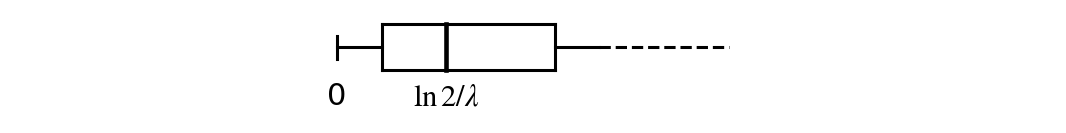

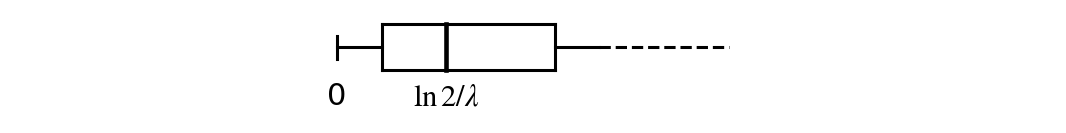

In [5]:
fig, ax = plt.subplots(figsize=(6, 0.3))

lambda_ = 1
first_quartile = (np.log(4) - np.log(3)) / lambda_
median = np.log(2) / lambda_
third_quartile = np.log(4) / lambda_

lw = 1
height = 0.2

plt.plot([median, median], [-height, height], c='k', linewidth=1.5)

plt.plot([0, 0], [-.1, .1], c='k', linewidth=lw)
plt.plot([0, first_quartile], [0, 0], c='k', linewidth=lw)

plt.plot([first_quartile, first_quartile], [-height, height],
         c='k', linewidth=lw)

plt.plot([third_quartile, third_quartile], [-height, height],
         c='k', linewidth=lw)

plt.plot([first_quartile, third_quartile], [height, height],
         c='k', linewidth=lw)
plt.plot([first_quartile, third_quartile], [-height, -height],
         c='k', linewidth=lw)

plt.plot([third_quartile, third_quartile*1.2], [0, 0], c='k', linewidth=lw)
plt.plot([third_quartile*1.2, third_quartile*1.8], [0, 0],
         'k--', linewidth=lw)

plt.text(0, -0.5, '0', ha='center')
plt.text(median, -0.5, r'$\ln 2/\lambda$', ha='center')

plt.axis('off')
pad = 2
plt.xlim(0-pad, 2.5+pad) 
plt.show()

glue("exponential-bp", fig)

```{glue:figure} exponential-bp
:name: fig:exponential-bp
:figwidth: 100%

Diagramma a scatola per la distribuzione esponenziale di parametro
$\lambda = 1$. Il baffo a destra della scatola è parzialmente tratteggiato
per enfatizzare il fatto che si estende fino a $+\infty$.

```

(sec:implementazione-modello-esponenziale)=
## Implementazione del modello esponenziale

In `scipy.stats` si ottiene un oggetto che descrive una distribuzione
esponenziale utilizzando la funzione `expon`. Come per tutti i modelli
continui, quando si invoca questa funzione senza specificare il valore
per alcun parametro, l'oggetto restituito fa riferimento a una distribuzione
specifica nella famiglia esponenziale, e precisamente quello che corrisponde
al parametro $\lambda = 1$. Se si vuole utilizzare una distribuzione
esponenziale per un generico valore $\lambda$ del parametro, è necessario
specificare l'argomento `scale` [^loc-param], impostandolo a $1 / \lambda$.
Ciò è dovuto al fatto che, in generale, il valore indicato per `scale`
modifica la deviazione standard della distribuzione, che nel caso del modello
esponenziale è uguale, appunto, a $1 / \lambda$.


[^loc-param]: Come per tutte le altre distribuzioni implementate in
`scipy.stats`, è anche possibile specificare un valore per il parametro `loc`,
con l'effetto di modificare la centralità della distribuzione ottenuta,
traslandola verso destra esattamente di una quantità uguale al valore che
è stato specificato. Ciò significa pertanto che l'oggetto ottenuto invocando
`expon` non descrive una distribuzione all'interno della famiglia
esponenziale, semplicemente perché il suo dominio non è $\mathbb R^+$.